# **IMPORT LIBRARY**

In [2]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tqdm import tqdm

In [3]:
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)

True

# **LOAD DATASET**

In [4]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1lWGOzr20bgHEf81abiICvcXGyyO3Hos4')
df.head()

,review,sentiment
0,This is an utterly forgettable picture. A frie...,negative
1,"Very suspenseful, surprisingly intelligent fil...",positive
2,"""Journey to the Far Side of the Sun"" (aka ""Dop...",positive
3,During the whole Pirates of The Caribbean Tril...,positive
4,I can't come up with appropriate enough words ...,negative


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     20000 non-null  object
 1   sentiment  20000 non-null  object
dtypes: object(2)
memory usage: 312.6+ KB


# **CASE FOLDING**

In [6]:
df['clean_review'] = df['review'].str.lower()
df[['review', 'clean_review']].head(5)

,review,clean_review
0,This is an utterly forgettable picture. A frie...,this is an utterly forgettable picture. a frie...
1,"Very suspenseful, surprisingly intelligent fil...","very suspenseful, surprisingly intelligent fil..."
2,"""Journey to the Far Side of the Sun"" (aka ""Dop...","""journey to the far side of the sun"" (aka ""dop..."
3,During the whole Pirates of The Caribbean Tril...,during the whole pirates of the caribbean tril...
4,I can't come up with appropriate enough words ...,i can't come up with appropriate enough words ...


# **DATA CLEANING**

In [7]:
def clean_data(text):
    text = text.str.strip()
    text = text.str.replace(r'[^a-zA-Z\s]', '', regex=True)
    text = text.str.replace(r' {2,}', ' ', regex=True).str.strip()
    text = text.str.replace(r'<br />', '', regex=True)
    text = text.str.replace(r'http\S+', '', regex=True)

    return text

df['clean_review'] = clean_data(df['clean_review'])
df[['review', 'clean_review']].head(5)

,review,clean_review
0,This is an utterly forgettable picture. A frie...,this is an utterly forgettable picture a frien...
1,"Very suspenseful, surprisingly intelligent fil...",very suspenseful surprisingly intelligent film...
2,"""Journey to the Far Side of the Sun"" (aka ""Dop...",journey to the far side of the sun aka doppelg...
3,During the whole Pirates of The Caribbean Tril...,during the whole pirates of the caribbean tril...
4,I can't come up with appropriate enough words ...,i cant come up with appropriate enough words t...


# **TOKENIZATION**

In [8]:
df['tokens'] = df['clean_review'].str.split()
df[['clean_review', 'tokens']].head(5)

,clean_review,tokens
0,this is an utterly forgettable picture a frien...,"[this, is, an, utterly, forgettable, picture, ..."
1,very suspenseful surprisingly intelligent film...,"[very, suspenseful, surprisingly, intelligent,..."
2,journey to the far side of the sun aka doppelg...,"[journey, to, the, far, side, of, the, sun, ak..."
3,during the whole pirates of the caribbean tril...,"[during, the, whole, pirates, of, the, caribbe..."
4,i cant come up with appropriate enough words t...,"[i, cant, come, up, with, appropriate, enough,..."


# **STOPWORD REMOVAL**

In [9]:
stopwords_english = set(stopwords.words('english'))
custom_stopwords = stopwords_english.union({'movie', 'film', 'one', 'make', 'even', 'see', 'watch', 'time', 'character', 'story'})

In [10]:
def remove_stopwords(tokens_list):
    return [word for word in tokens_list if word not in custom_stopwords]

In [11]:
tqdm.pandas(desc="Menghapus Stopword")
df['tokens_no_stopword'] = df['tokens'].progress_apply(remove_stopwords)
df[['tokens', 'tokens_no_stopword']].head(5)

Menghapus Stopword: 100%|██████████| 20000/20000 [00:00<00:00, 34578.59it/s]


,tokens,tokens_no_stopword
0,"[this, is, an, utterly, forgettable, picture, ...","[utterly, forgettable, picture, friend, mine, ..."
1,"[very, suspenseful, surprisingly, intelligent,...","[suspenseful, surprisingly, intelligent, five,..."
2,"[journey, to, the, far, side, of, the, sun, ak...","[journey, far, side, sun, aka, doppelganger, e..."
3,"[during, the, whole, pirates, of, the, caribbe...","[whole, pirates, caribbean, trilogy, craze, pa..."
4,"[i, cant, come, up, with, appropriate, enough,...","[cant, come, appropriate, enough, words, descr..."


# **LEMMATIZATION**

In [12]:
lemmatizer = WordNetLemmatizer()

In [13]:
def apply_lemmatization(tokens_list):
    return [lemmatizer.lemmatize(word) for word in tokens_list]

In [14]:
tqdm.pandas(desc="Lemmatization")
df['lemmatized_tokens'] = df['tokens_no_stopword'].progress_apply(apply_lemmatization)
df[['tokens_no_stopword', 'lemmatized_tokens']].head(5)

Lemmatization: 100%|██████████| 20000/20000 [00:15<00:00, 1260.22it/s]


,tokens_no_stopword,lemmatized_tokens
0,"[utterly, forgettable, picture, friend, mine, ...","[utterly, forgettable, picture, friend, mine, ..."
1,"[suspenseful, surprisingly, intelligent, five,...","[suspenseful, surprisingly, intelligent, five,..."
2,"[journey, far, side, sun, aka, doppelganger, e...","[journey, far, side, sun, aka, doppelganger, e..."
3,"[whole, pirates, caribbean, trilogy, craze, pa...","[whole, pirate, caribbean, trilogy, craze, par..."
4,"[cant, come, appropriate, enough, words, descr...","[cant, come, appropriate, enough, word, descri..."


# **TOKEN N LEMMA**

In [15]:
import spacy

In [16]:
nlp = spacy.load('en_core_web_sm')
phrase = df.loc[1, 'clean_review']
phrase

'very suspenseful surprisingly intelligent film about five medical students flatlining themselves and then being resuscitated to share their experiences of death and what lies beyond joel schumacher directs with some skill creating some very eerie scenes as well as particularly beautiful ones the visions of death are not what viewers might expect nor is that which awaits us all when we go thanks to screenwriter peter filardi who really did an outstanding job coming up with this story while the creativity of the story is impressive the story has many holes as well particularly in the logic department and believability factors notwithstanding all of that flatliners is a good effective film because of the script the direction which again is very surreal at times and the acting which brings four very talented actors and william baldwin together this core of actors acts and reacts off each other very nicely keifer sutherland does a very impressive job as the head of the group the one who co

In [17]:
doc = nlp(phrase)
doc

very suspenseful surprisingly intelligent film about five medical students flatlining themselves and then being resuscitated to share their experiences of death and what lies beyond joel schumacher directs with some skill creating some very eerie scenes as well as particularly beautiful ones the visions of death are not what viewers might expect nor is that which awaits us all when we go thanks to screenwriter peter filardi who really did an outstanding job coming up with this story while the creativity of the story is impressive the story has many holes as well particularly in the logic department and believability factors notwithstanding all of that flatliners is a good effective film because of the script the direction which again is very surreal at times and the acting which brings four very talented actors and william baldwin together this core of actors acts and reacts off each other very nicely keifer sutherland does a very impressive job as the head of the group the one who com

In [18]:
[token for token in doc]

[very,
 suspenseful,
 surprisingly,
 intelligent,
 film,
 about,
 five,
 medical,
 students,
 flatlining,
 themselves,
 and,
 then,
 being,
 resuscitated,
 to,
 share,
 their,
 experiences,
 of,
 death,
 and,
 what,
 lies,
 beyond,
 joel,
 schumacher,
 directs,
 with,
 some,
 skill,
 creating,
 some,
 very,
 eerie,
 scenes,
 as,
 well,
 as,
 particularly,
 beautiful,
 ones,
 the,
 visions,
 of,
 death,
 are,
 not,
 what,
 viewers,
 might,
 expect,
 nor,
 is,
 that,
 which,
 awaits,
 us,
 all,
 when,
 we,
 go,
 thanks,
 to,
 screenwriter,
 peter,
 filardi,
 who,
 really,
 did,
 an,
 outstanding,
 job,
 coming,
 up,
 with,
 this,
 story,
 while,
 the,
 creativity,
 of,
 the,
 story,
 is,
 impressive,
 the,
 story,
 has,
 many,
 holes,
 as,
 well,
 particularly,
 in,
 the,
 logic,
 department,
 and,
 believability,
 factors,
 notwithstanding,
 all,
 of,
 that,
 flatliners,
 is,
 a,
 good,
 effective,
 film,
 because,
 of,
 the,
 script,
 the,
 direction,
 which,
 again,
 is,
 very,
 surre

In [19]:
[token.lemma_ for token in doc]

['very',
 'suspenseful',
 'surprisingly',
 'intelligent',
 'film',
 'about',
 'five',
 'medical',
 'student',
 'flatline',
 'themselves',
 'and',
 'then',
 'be',
 'resuscitate',
 'to',
 'share',
 'their',
 'experience',
 'of',
 'death',
 'and',
 'what',
 'lie',
 'beyond',
 'joel',
 'schumacher',
 'direct',
 'with',
 'some',
 'skill',
 'create',
 'some',
 'very',
 'eerie',
 'scene',
 'as',
 'well',
 'as',
 'particularly',
 'beautiful',
 'one',
 'the',
 'vision',
 'of',
 'death',
 'be',
 'not',
 'what',
 'viewer',
 'might',
 'expect',
 'nor',
 'be',
 'that',
 'which',
 'await',
 'we',
 'all',
 'when',
 'we',
 'go',
 'thank',
 'to',
 'screenwriter',
 'peter',
 'filardi',
 'who',
 'really',
 'do',
 'an',
 'outstanding',
 'job',
 'come',
 'up',
 'with',
 'this',
 'story',
 'while',
 'the',
 'creativity',
 'of',
 'the',
 'story',
 'be',
 'impressive',
 'the',
 'story',
 'have',
 'many',
 'hole',
 'as',
 'well',
 'particularly',
 'in',
 'the',
 'logic',
 'department',
 'and',
 'believability'

In [20]:
df.columns

Index(['review', 'sentiment', 'clean_review', 'tokens', 'tokens_no_stopword',
       'lemmatized_tokens'],
      dtype='object')

In [21]:
df['clean_text'] = df['lemmatized_tokens'].apply(lambda x: " ".join(x))

#**FEATURE EXTRACTION**

##**TF-IDF**

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_text'])

y = df['sentiment']

In [23]:
print("Shape TF-IDF:", X_tfidf.shape)

Shape TF-IDF: (20000, 5000)


In [24]:
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())
tfidf_df.head()

,abandoned,abc,ability,able,abortion,aboutbr,absence,absent,absolute,absolutely,...,youll,young,younger,youngster,youre,youth,youve,zero,zombie,zone
0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.062934,0.0,0.077325,0.000000,0.0,0.000000
1,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.062115,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000
2,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.085626
3,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000
4,0.0,0.0,0.0,0.049263,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.045074,0.0,0.000000,0.065362,0.0,0.000000


##**Word Embedding**

In [25]:
import sys
!{sys.executable} -m pip install gensim
from gensim.models import Word2Vec

# ambil token
sentences = df['lemmatized_tokens']

# training model
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 40.0 MB/s eta 0:00:00


In [26]:
import numpy as np

def sentence_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

X_w2v = np.array([sentence_vector(tokens, w2v_model) for tokens in sentences])

print("Shape Word2Vec:", X_w2v.shape)

Shape Word2Vec: (20000, 100)


In [27]:
print("Contoh vector Word2Vec:")
print(X_w2v[0])

Contoh vector Word2Vec:
[-0.09027456  0.22429602  0.18419024 -0.06264217 -0.13153388 -0.57983845
  0.25254124  1.1584442  -0.71853703 -0.32486168 -0.34825248 -0.68233204
  0.29129702  0.12244451  0.16177629 -0.1021905   0.29243624 -0.39816576
 -0.09551044 -1.2342687   0.28058526  0.1466054   0.2902516  -0.56685334
 -0.29616144  0.1511061  -0.28357387 -0.32928187  0.01193398  0.01584096
  0.5773741  -0.00598374  0.19580033 -0.47103602 -0.3112907   0.6989113
  0.16447236 -0.1954407  -0.23347406 -0.70068854  0.10585317 -0.49979582
 -0.18540454 -0.04914029  0.16472489 -0.1346085  -0.3796208   0.11942484
  0.36714402  0.10531646 -0.07381393 -0.28986615  0.02443255  0.16010283
 -0.13545819  0.01558183  0.45990863  0.1259     -0.3447465   0.43694612
 -0.08952548  0.06309886  0.16734125  0.01536705 -0.4372229   0.3493074
  0.28154355  0.4001381  -0.39789793  0.44441205 -0.11773913  0.01078556
  0.3969303   0.29771358  0.6313525   0.10987946  0.14757274  0.2503053
 -0.03870803  0.1419948  -0.32

In [28]:
df['sentiment'].value_counts()

,count
sentiment,
negative,10000
positive,10000


#**MODELING**

##**Splitting Data Train dan Data Test**

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Target label
y = df['sentiment']

# Split untuk TF-IDF
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
# Split untuk Word2Vec
X_train_w2v, X_test_w2v, _, _ = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42, stratify=y
)

In [31]:
# Fungsi bantuan untuk menghitung semua metrik sekaligus
def get_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, pos_label='positive'),
        'Recall': recall_score(y_true, y_pred, pos_label='positive'),
        'F1-Score': f1_score(y_true, y_pred, pos_label='positive')
    }

print("Data Splitting Selesai!")

Data Splitting Selesai!


##**Training 3 Model Klasifikasi**

###**1. Logistic Regression**


In [32]:
from sklearn.linear_model import LogisticRegression

# Inisialisasi
lr = LogisticRegression(max_iter=1000)

# Training & Test pada TF-IDF
lr.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [33]:
metrics_lr_tfidf = get_metrics(y_test, lr.predict(X_test_tfidf))

In [34]:
# Training & Test pada Word2Vec
lr.fit(X_train_w2v, y_train)

LogisticRegression(max_iter=1000)

In [35]:
metrics_lr_w2v = get_metrics(y_test, lr.predict(X_test_w2v))

###**2. Support Vector Machine (SVM)**

Kami menggunakan Linear SVC agar waktu running lebih cepat namun tetap akurat untuk dimensi tinggi.

In [36]:
from sklearn.svm import LinearSVC

# Inisialisasi
svm = LinearSVC(random_state=42)


In [37]:
# Training & Test pada TF-IDF
svm.fit(X_train_tfidf, y_train)

LinearSVC(random_state=42)

In [38]:
metrics_svm_tfidf = get_metrics(y_test, svm.predict(X_test_tfidf))

In [39]:
# Training & Test pada Word2Vec
svm.fit(X_train_w2v, y_train)

LinearSVC(random_state=42)

In [40]:
metrics_svm_w2v = get_metrics(y_test, svm.predict(X_test_w2v))

###**3. Random Forest**

kami memilih random forest karena fleksibilitas data, menangkap pola kompleks, dan memberikan variasi

In [41]:
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [42]:
# Training & Test pada TF-IDF
rf.fit(X_train_tfidf, y_train)

RandomForestClassifier(random_state=42)

In [43]:
metrics_rf_tfidf = get_metrics(y_test, rf.predict(X_test_tfidf))

In [44]:
# Training & Test pada Word2Vec
rf.fit(X_train_w2v, y_train)

RandomForestClassifier(random_state=42)

In [45]:
metrics_rf_w2v = get_metrics(y_test, rf.predict(X_test_w2v))

In [46]:
final_results = [
    {'Model': 'Logistic Regression', 'Feature': 'TF-IDF', **metrics_lr_tfidf},
    {'Model': 'Logistic Regression', 'Feature': 'Word2Vec', **metrics_lr_w2v},
    {'Model': 'SVM', 'Feature': 'TF-IDF', **metrics_svm_tfidf},
    {'Model': 'SVM', 'Feature': 'Word2Vec', **metrics_svm_w2v},
    {'Model': 'Random Forest', 'Feature': 'TF-IDF', **metrics_rf_tfidf},
    {'Model': 'Random Forest', 'Feature': 'Word2Vec', **metrics_rf_w2v},
]

df_report = pd.DataFrame(final_results)
# Mengurutkan berdasarkan Accuracy tertinggi
df_report = df_report.sort_values(by='Accuracy', ascending=False)
df_report

,Model,Feature,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,TF-IDF,0.87725,0.866084,0.8925,0.879094
2,SVM,TF-IDF,0.86125,0.853301,0.8725,0.862794
4,Random Forest,TF-IDF,0.84150,0.846701,0.8340,0.840302
1,Logistic Regression,Word2Vec,0.83600,0.831034,0.8435,0.837221
3,SVM,Word2Vec,0.83475,0.829316,0.8430,0.836102
5,Random Forest,Word2Vec,0.81275,0.801737,0.8310,0.816106


#**COMPARISON MODEL**

##**Ranking Model Terbaik**

In [47]:
df_sorted = df_report.sort_values(by="F1-Score", ascending=False)
df_sorted

,Model,Feature,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,TF-IDF,0.87725,0.866084,0.8925,0.879094
2,SVM,TF-IDF,0.86125,0.853301,0.8725,0.862794
4,Random Forest,TF-IDF,0.84150,0.846701,0.8340,0.840302
1,Logistic Regression,Word2Vec,0.83600,0.831034,0.8435,0.837221
3,SVM,Word2Vec,0.83475,0.829316,0.8430,0.836102
5,Random Forest,Word2Vec,0.81275,0.801737,0.8310,0.816106


##**Perbandingan Feature Extraction (TF-IDF vs Word2Vec)**

In [48]:
feature_comparison = df_report.groupby("Feature")[["Accuracy", "Precision", "Recall", "F1-Score"]].mean()
feature_comparison

,Accuracy,Precision,Recall,F1-Score
Feature,,,,
TF-IDF,0.860000,0.855362,0.866333,0.86073
Word2Vec,0.827833,0.820696,0.839167,0.82981


##**Perbandingan Model (LR vs SVM vs RF)**

In [49]:
model_comparison = df_report.groupby("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].mean()
model_comparison

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.856625,0.848559,0.86800,0.858157
Random Forest,0.827125,0.824219,0.83250,0.828204
SVM,0.848000,0.841309,0.85775,0.849448


##**Pivot Table**

In [50]:
pivot = df_report.pivot(index="Model", columns="Feature", values="F1-Score")
pivot

Feature,TF-IDF,Word2Vec
Model,,
Logistic Regression,0.879094,0.837221
Random Forest,0.840302,0.816106
SVM,0.862794,0.836102


##**Visualisasi Perbandingan Model dan Fitur**

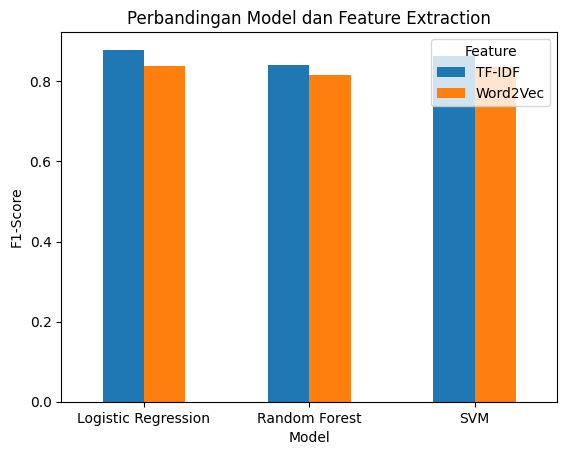

In [51]:
import matplotlib.pyplot as plt

pivot.plot(kind='bar')
plt.title("Perbandingan Model dan Feature Extraction")
plt.ylabel("F1-Score")
plt.xticks(rotation=0)
plt.show()

# **Deployment**

In [52]:
lr_final = LogisticRegression(max_iter=1000)
lr_final.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [55]:
# Mendeploy

import gradio as gr

def predict_sentiment(review):
    review_lower = review.lower()

    review_clean = re.sub(r'[^a-zA-Z\s]', '', review_lower)
    review_clean = re.sub(r' {2,}', ' ', review_clean).strip()

    tokens = review_clean.split()
    filtered_tokens = [word for word in tokens if word not in custom_stopwords]

    lemmatized = [lemmatizer.lemmatize(word) for word in filtered_tokens]
    final_text = " ".join(lemmatized)

    tfidf_vector = tfidf.transform([final_text])

    prediction = lr_final.predict(tfidf_vector)[0]

    probs = lr_final.predict_proba(tfidf_vector)[0]
    return {
        "Sentiment": prediction,
        "Confidence": f"{max(probs) * 100:.2f}%"
    }

interface = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=3, placeholder="Masukkan review film di sini...", label="Input Review"),
    outputs=[gr.JSON(label="Hasil Prediksi")],
    title="🎬 Movie Review Sentiment Analysis",
    description="Project NLP Kelompok Vectro: Klasifikasi sentiment positif/negatif menggunakan Logistic Regression & TF-IDF.",
    examples=[
        ["This movie was absolutely amazing! The plot and acting were top notch."],
        ["Utterly forgettable and a waste of time. I do not recommend it."]
    ],
    theme="soft"
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://78587609b9a66f9bc0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
